# 자치구별 일 최대 생활인구(인구 밀집) 예측
- 목표 : 전일·7일전 인구 정보로 오늘의 일최대인구수 예측
- 방식 : 회귀 모델 6종 비교 → 정확도 최고 모델 선택 → 예측 결과 시각화
- 정확도 : (1 - MAPE) × 100, 실제값 대비 평균 오차 비율을 뺀 값

## 0. 라이브러리 및 기본 설정
- 한글 폰트 설정 : 그래프 한글 깨짐 방지
- 결과 폴더 생성 : 모델·그래프·예측표 저장 위치

In [1]:
import os
import pickle
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

DATA_DIR = './ml_data'        # 학습용 csv 폴더
RESULT_DIR = './ml_result'    # 결과 저장 폴더
os.makedirs(RESULT_DIR, exist_ok=True)

## 1. 데이터 불러오기 및 확인
- 날짜형 변환 : 문자열 → datetime (pd.to_datetime)
- 정렬 : 자치구 → 날짜 순서

In [2]:
df = pd.read_csv(f'{DATA_DIR}/population_selected.csv', encoding='utf-8-sig')
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values(['District', 'ds']).reset_index(drop=True)

print(df.shape)
print(df.head())
print(df.isna().sum())
print('기간 :', df['ds'].min(), '~', df['ds'].max())

(75825, 8)
          ds District    7일전_일최대인구수  전일_Night_Pop  전일_일최대이동인구수  \
0 2018-04-12      강남구  1.147911e+06   773343.3511  748381.9632   
1 2018-04-13      강남구  1.151434e+06   780245.6758  755681.2506   
2 2018-04-14      강남구  9.206919e+05   778317.8563  744407.8148   
3 2018-04-15      강남구  8.256871e+05   721487.7636  497627.1898   
4 2018-04-16      강남구  1.127112e+06   688217.5094  403246.4693   

   전일_동일자치구행정동간이동인구수  전일_Pop_Diff        일최대인구수  
0        138173.1101  325148.4480  1.141658e+06  
1        138339.7021  323385.3593  1.138334e+06  
2        137947.1677  318208.7419  9.172530e+05  
3        125476.8579  149661.7714  7.984891e+05  
4        125258.2477   84917.8721  1.118871e+06  
ds                   0
District             0
7일전_일최대인구수           0
전일_Night_Pop         0
전일_일최대이동인구수          0
전일_동일자치구행정동간이동인구수    0
전일_Pop_Diff          0
일최대인구수               0
dtype: int64
기간 : 2018-04-12 00:00:00 ~ 2026-07-31 00:00:00


## 2. 전처리 (날짜 특성 추가)
- 요일 : 0(월) ~ 6(일), 평일·주말 인구 차이 반영
- 월 : 계절에 따른 차이 반영
- 주말여부 : 토·일이면 1
- 원-핫 인코딩 : 자치구 이름 → 0/1 컬럼

In [3]:
df['요일'] = df['ds'].dt.dayofweek
df['월'] = df['ds'].dt.month
df['주말여부'] = (df['요일'] >= 5).astype(int)

features = ['7일전_일최대인구수', '전일_Night_Pop', '전일_일최대이동인구수',
            '전일_동일자치구행정동간이동인구수', '전일_Pop_Diff', '요일', '월', '주말여부']
target = '일최대인구수'

X = pd.get_dummies(df[features + ['District']], columns=['District'], dtype=int)
y = df[target]
print(X.shape)

(75825, 33)


## 2-1. 자치구별 요일 효과 확인
- 전체 상관이 약했던 이유 : 구마다 인구 규모 차이가 커서 요일 효과가 가려짐
- 해결 : 구별 평균으로 나눈 비율 (1보다 크면 평균보다 많음, 작으면 적음)
- pivot_table : 행=자치구, 열=요일, 값=평균 인구
- 해석 : 업무지구는 주말 감소, 주거지역은 주말 증가 또는 변화 적음

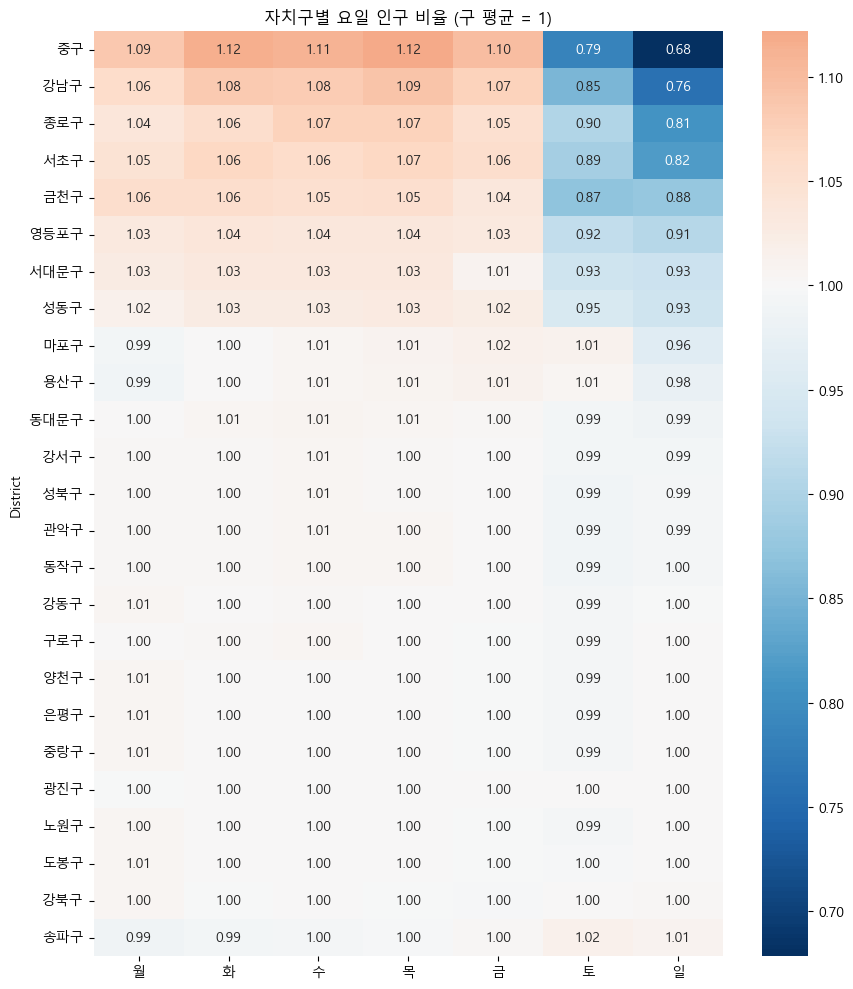

주말 인구 변화율(%)
District
중구     -26.7
강남구    -19.4
서초구    -14.6
종로구    -14.4
금천구    -12.6
영등포구    -8.6
서대문구    -6.8
성동구     -5.9
마포구     -1.3
동대문구    -1.2
용산구     -1.0
강서구     -0.9
관악구     -0.9
동작구     -0.8
성북구     -0.8
강동구     -0.5
구로구     -0.4
양천구     -0.3
은평구     -0.3
노원구     -0.3
중랑구     -0.2
도봉구     -0.1
광진구     -0.0
강북구      0.1
송파구      1.5
dtype: float64


In [4]:
day_ratio = df.pivot_table(index='District', columns='요일', values=target, aggfunc='mean')
day_ratio = day_ratio.div(day_ratio.mean(axis=1), axis=0)
day_ratio.columns = ['월', '화', '수', '목', '금', '토', '일']
day_ratio = day_ratio.sort_values('일')

plt.figure(figsize=(9, 10))
sns.heatmap(day_ratio, annot=True, fmt='.2f', cmap='RdBu_r', center=1)
plt.title('자치구별 요일 인구 비율 (구 평균 = 1)')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/population_weekday_by_gu.png')
plt.show()

weekend_ratio = (day_ratio[['토', '일']].mean(axis=1) - 1) * 100
print('주말 인구 변화율(%)')
print(weekend_ratio.sort_values().round(1))

## 3. 데이터셋 분할 (날짜 기준)
- 시간 순서 분할 : 과거로 학습, 최근으로 평가 (미래 정보 누출 방지)
- 시험 데이터 : 마지막 1년 (2025-08-01 이후)

In [5]:
split_date = '2025-08-01'
train_mask = df['ds'] < split_date
test_mask = df['ds'] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
print('학습 :', X_train.shape, '/ 시험 :', X_test.shape)

학습 : (66700, 33) / 시험 : (9125, 33)


## 4. 스케일 조정
- StandardScaler : 평균 0, 표준편차 1로 변환
- fit은 학습 데이터에만 : 시험 데이터 정보 누출 방지

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 5. 평가 함수
- MAE : 오차 절댓값 평균
- RMSE : 오차 제곱 평균의 제곱근 (큰 오차에 민감)
- R2 : 실제값 변동을 설명하는 비율 (1에 가까울수록 좋음)
- 정확도(%) : (1 - MAPE) × 100

In [7]:
def evaluate(name, y_true, y_pred):
    return {
        '모델': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        '정확도(%)': (1 - mean_absolute_percentage_error(y_true, y_pred)) * 100
    }

## 6. 머신러닝 모델 5종 학습
- 선형회귀 : 입력과 타겟의 직선 관계
- 릿지 : 선형회귀 + 가중치 크기 제한 (과적합 방지)
- 결정트리 : 조건 분기로 값 예측
- 랜덤포레스트 : 여러 결정트리의 평균
- 그래디언트부스팅 : 앞 트리의 오차를 다음 트리가 보완
- n_jobs=-1 : CPU 코어 전체 사용 (학습 속도 향상)

In [8]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'DecisionTree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    predictions[name] = pred
    results.append(evaluate(name, y_test, pred))
    print(name, '학습 완료')

LinearRegression 학습 완료
Ridge 학습 완료
DecisionTree 학습 완료
RandomForest 학습 완료
GradientBoosting 학습 완료


## 7. 딥러닝 모델 (DNN) 학습
- 타겟 스케일 조정 : 수십만 단위 값을 작게 만들어 학습 안정화
- Dense → Dropout : 전결합층 + 과적합 방지
- EarlyStopping : 검증 오차 개선이 없으면 학습 중단
- inverse_transform : 예측값을 원래 단위로 복원

286/286 [==============================] - 0s 505us/step


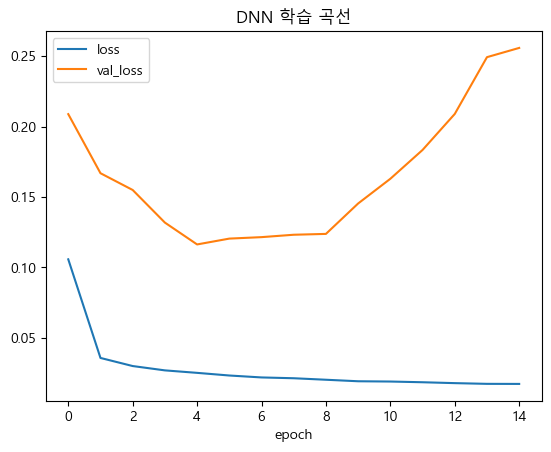

In [9]:
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.values.reshape(-1, 1))

dnn = Sequential([
    Input(shape=(X_train_s.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

dnn.compile(loss='mse', optimizer='adam', metrics=['mae'])

hist = dnn.fit(
    X_train_s, y_train_s,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=0
)

pred_dnn = y_scaler.inverse_transform(dnn.predict(X_test_s)).flatten()
predictions['DNN'] = pred_dnn
results.append(evaluate('DNN', y_test, pred_dnn))

plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_loss'], label='val_loss')
plt.title('DNN 학습 곡선')
plt.xlabel('epoch')
plt.legend()
plt.show()

## 8. 모델 성능 비교 및 최고 모델 선택
- 정렬 기준 : 정확도(%) 내림차순
- 최고 모델 저장 : 머신러닝은 pickle, 딥러닝은 h5

In [10]:
result_df = pd.DataFrame(results).sort_values('정확도(%)', ascending=False).reset_index(drop=True)
print(result_df.round(3))

best_name = result_df.loc[0, '모델']
best_pred = predictions[best_name]
print('최고 모델 :', best_name)

if best_name == 'DNN':
    dnn.save(f'{RESULT_DIR}/population_best_model.h5')
else:
    with open(f'{RESULT_DIR}/population_best_model.pkl', 'wb') as f:
        pickle.dump(models[best_name], f)

with open(f'{RESULT_DIR}/population_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

result_df.to_csv(f'{RESULT_DIR}/population_model_score.csv', index=False, encoding='utf-8-sig')

                 모델        MAE       RMSE     R2  정확도(%)
0      RandomForest   8723.367  20822.038  0.986  98.175
1  GradientBoosting   9361.539  20994.811  0.986  97.992
2      DecisionTree  11350.535  26822.558  0.977  97.532
3             Ridge  13959.365  30773.080  0.969  97.136
4  LinearRegression  13967.067  30764.459  0.969  97.131
5               DNN  27086.679  37485.896  0.954  93.777
최고 모델 : RandomForest


## 9. 시각화 ① 모델별 정확도 비교
- 막대그래프 : 모델 간 성능 차이 한눈에 비교
- 최고 모델 강조 : 빨간색 막대

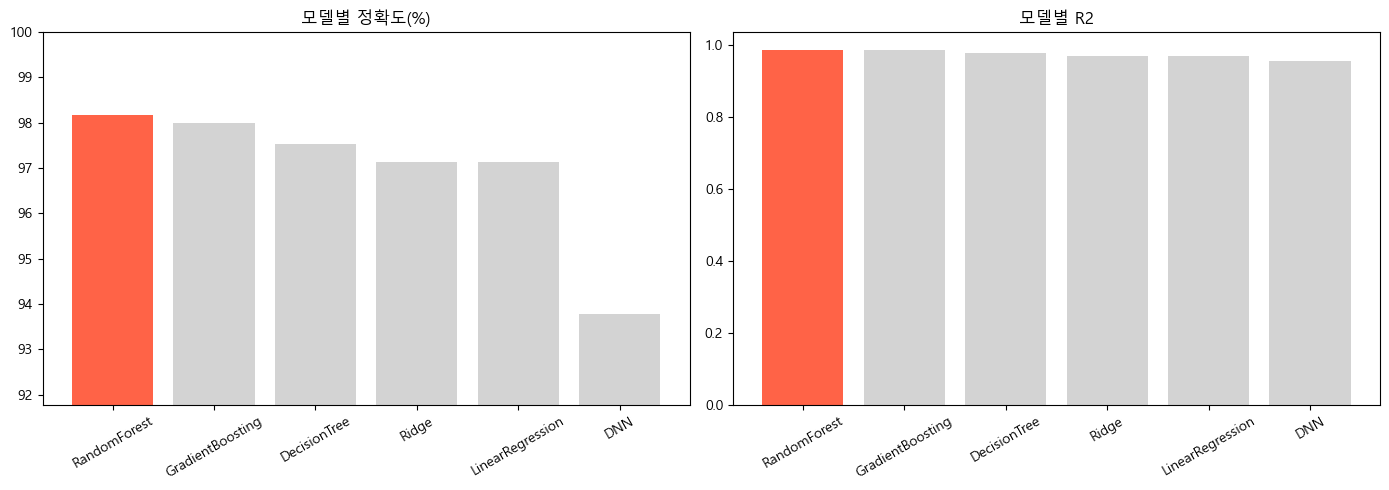

In [11]:
colors = ['tomato' if m == best_name else 'lightgray' for m in result_df['모델']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(result_df['모델'], result_df['정확도(%)'], color=colors)
axes[0].set_title('모델별 정확도(%)')
axes[0].set_ylim(result_df['정확도(%)'].min() - 2, 100)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(result_df['모델'], result_df['R2'], color=colors)
axes[1].set_title('모델별 R2')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/population_model_compare.png')
plt.show()

## 10. 시각화 ② 실제값 vs 예측값 산점도
- 대각선(y=x) : 완벽한 예측선
- 점이 대각선에 가까울수록 정확한 예측

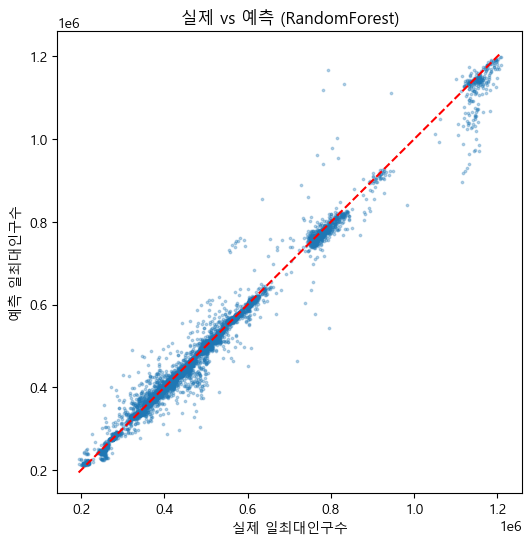

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, s=3, alpha=0.3)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, 'r--')
plt.xlabel('실제 일최대인구수')
plt.ylabel('예측 일최대인구수')
plt.title(f'실제 vs 예측 ({best_name})')
plt.savefig(f'{RESULT_DIR}/population_scatter.png')
plt.show()

## 11. 시각화 ③ 인구 상위 4개 자치구의 테스트 기간 추이
- 파란 실선 : 실제값
- 빨간 점선 : 예측값
- 주기적 오르내림 : 평일·주말 인구 차이

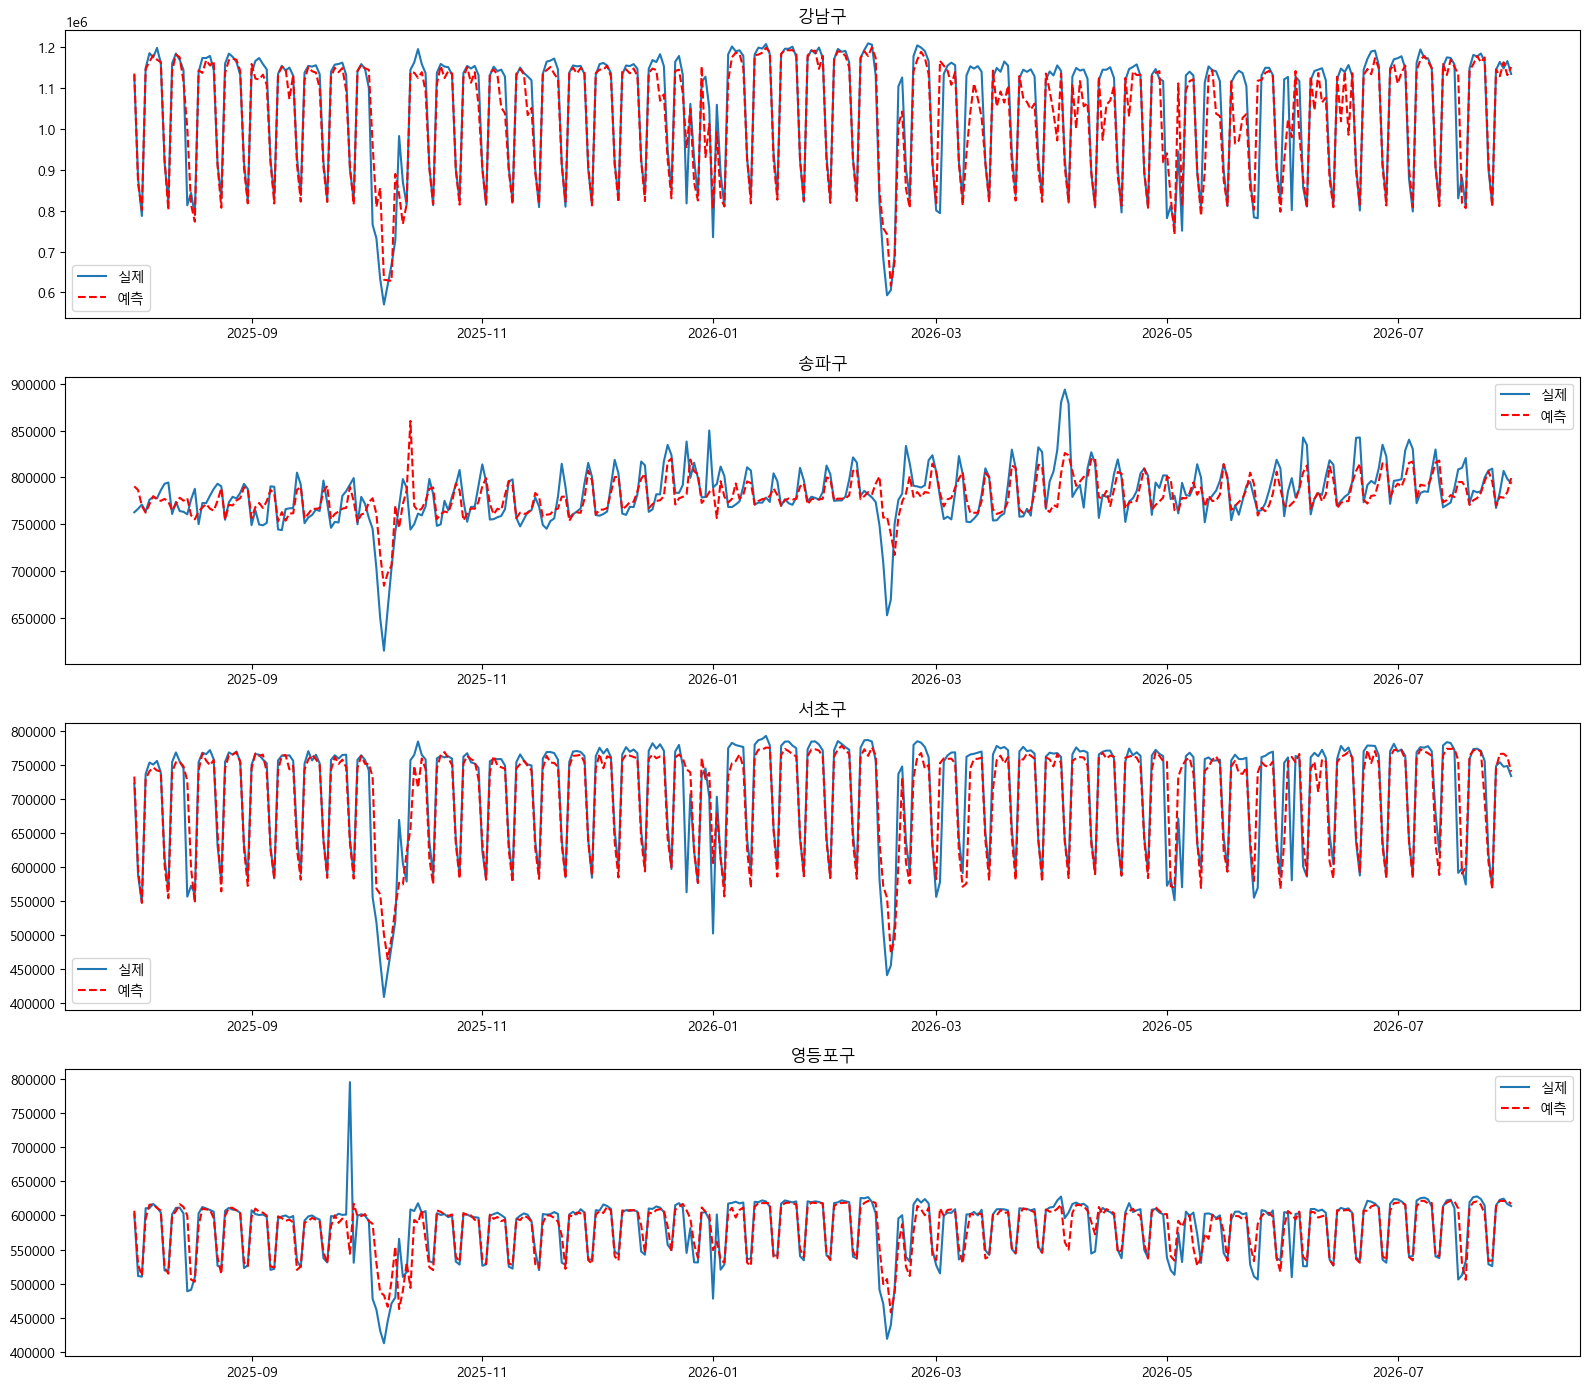

In [13]:
test_df = df.loc[test_mask, ['ds', 'District', target]].copy()
test_df['예측'] = best_pred
test_df['오차율(%)'] = (test_df['예측'] - test_df[target]).abs() / test_df[target] * 100
test_df.to_csv(f'{RESULT_DIR}/population_test_prediction.csv', index=False, encoding='utf-8-sig')

top4 = df.groupby('District')[target].mean().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
for ax, gu in zip(axes, top4):
    part = test_df[test_df['District'] == gu]
    ax.plot(part['ds'], part[target], label='실제')
    ax.plot(part['ds'], part['예측'], 'r--', label='예측')
    ax.set_title(gu)
    ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/population_trend.png')
plt.show()

## 12. 시각화 ④ 자치구별 평균 오차율
- 오차율 : |예측 - 실제| / 실제 × 100
- 오차율 높은 자치구 : 예측이 어려운 지역 (추가 변수 검토 대상)

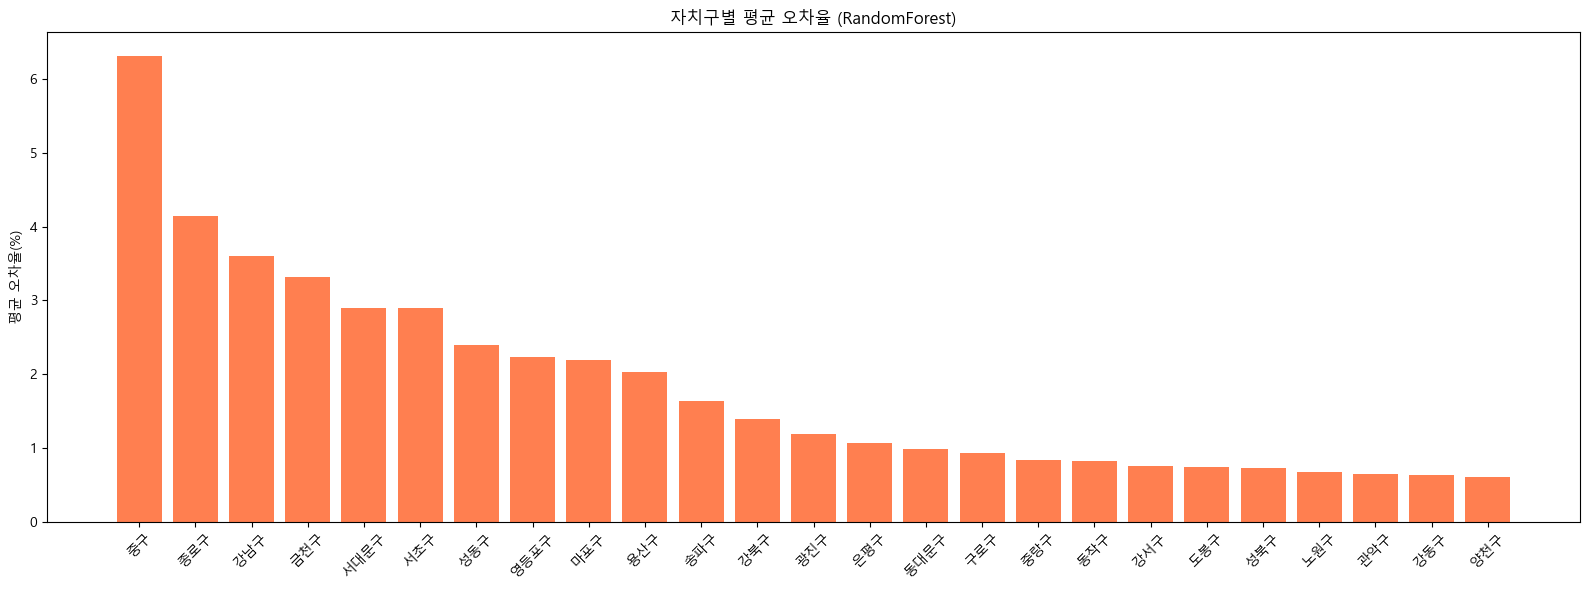

In [14]:
gu_err = test_df.groupby('District')['오차율(%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 6))
plt.bar(gu_err.index, gu_err.values, color='coral')
plt.xticks(rotation=45)
plt.ylabel('평균 오차율(%)')
plt.title(f'자치구별 평균 오차율 ({best_name})')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/population_district_error.png')
plt.show()

## 13. 시각화 ⑤ 요일별 평균 인구 : 실제 vs 예측
- 요일 패턴 : 모델이 평일·주말 차이를 잘 잡았는지 확인
- 묶음 막대그래프 : 요일마다 실제·예측 나란히 표시

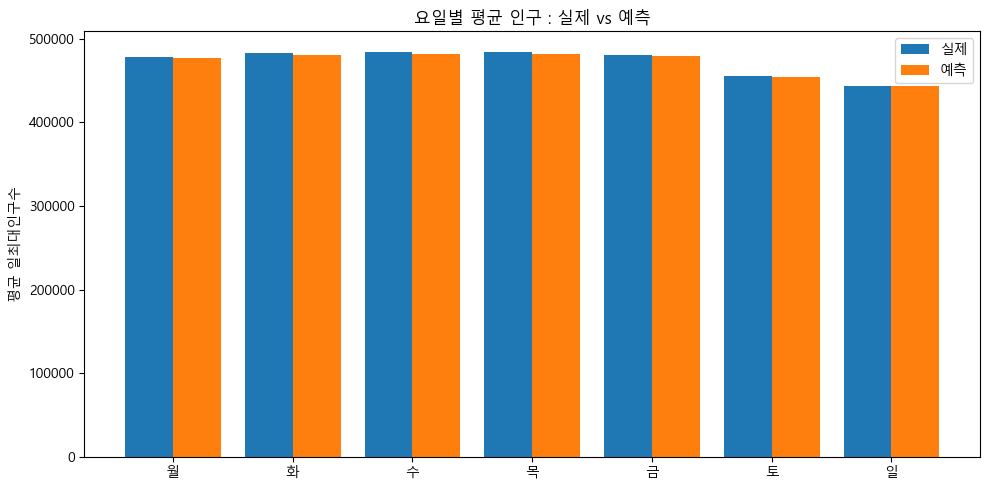

In [15]:
test_df['요일'] = test_df['ds'].dt.dayofweek
day_mean = test_df.groupby('요일')[[target, '예측']].mean()
day_names = ['월', '화', '수', '목', '금', '토', '일']

x = np.arange(7)
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, day_mean[target], width=0.4, label='실제')
plt.bar(x + 0.2, day_mean['예측'], width=0.4, label='예측')
plt.xticks(x, day_names)
plt.ylabel('평균 일최대인구수')
plt.title('요일별 평균 인구 : 실제 vs 예측')
plt.legend()
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/population_weekday.png')
plt.show()

## 14. 특성 중요도 확인
- 목적 : 상관계수가 놓친 곡선 관계·여러 컬럼의 조합 효과 확인
- 기준 모델 : RandomForest (트리 모델은 중요도를 바로 계산 가능)
- 중요도 원리 : 해당 컬럼으로 나눴을 때 오차가 줄어든 양의 합
- 자치구 컬럼 합산 : 원-핫으로 쪼개진 District_ 컬럼을 하나로 묶어서 보기

7일전_일최대인구수           0.960
전일_Night_Pop         0.014
전일_Pop_Diff          0.011
전일_일최대이동인구수          0.004
District(합계)         0.003
전일_동일자치구행정동간이동인구수    0.003
요일                   0.003
주말여부                 0.002
월                    0.001
dtype: float64


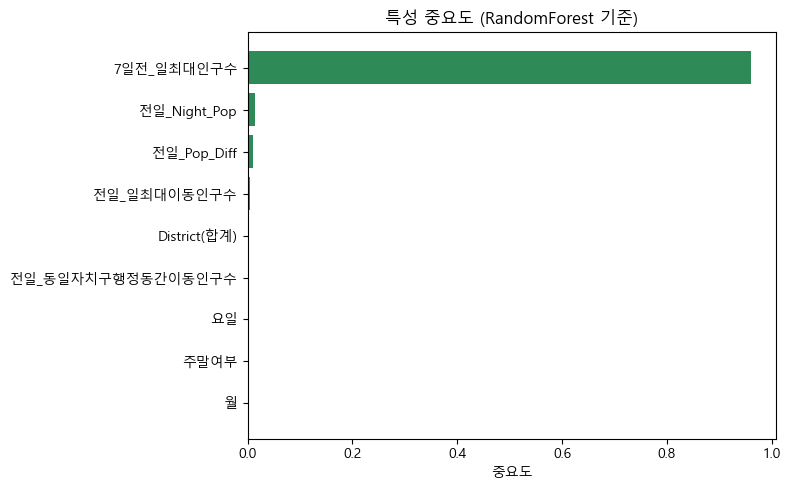

In [16]:
rf = models['RandomForest']
imp = pd.Series(rf.feature_importances_, index=X.columns)

gu_cols = [c for c in imp.index if c.startswith('District_')]
imp['District(합계)'] = imp[gu_cols].sum()
imp = imp.drop(gu_cols).sort_values()
print(imp.sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 5))
plt.barh(imp.index, imp.values, color='seagreen')
plt.xlabel('중요도')
plt.title('특성 중요도 (RandomForest 기준)')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/population_importance.png')
plt.show()